open proyecto → bring changes from  GitHub → work → save → git add → git commit → git push

BONDS
# Bonds & Yields Project

## Risk Management - Valuation and Hedging

This project studies the valuation and hedging of bonds using spot rates, forward rates, YTM, duration, DV01 and convexity. The analysis is based on ECB spot yields

Question1
Define a bond and explain how it is issued. Explain the relationship between bonds and interest rates.

A bond is a fixed-income security that represents a loan made by an investor to an issuer. Bonds are typically issued by governments, financial institutions, or corporations, and they generally provide periodic coupon payments together with the repayment of principal at maturity. From the investor’s perspective, bonds are often used to generate relatively stable income and to diversify a portfolio.

A key characteristic of bonds is the inverse relationship between bond prices and market interest rates. When market interest rates increase, the price of existing fixed-rate bonds decreases. This is because the value of a bond depends on the present value of its future cash flows. If newly issued bonds offer higher yields, previously issued bonds with lower coupon rates become less attractive, so their prices must fall to remain competitive in the market.

Question 2 data selection



In [1]:
import pandas as pd

#  Read raw data
raw_path = "../data/raw/ecb_spot_rates_raw.csv"
df_raw = pd.read_csv(raw_path)

print(df_raw.columns.tolist())
print(df_raw.head())

['DATE', 'TIME PERIOD', 'AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y)', 'AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M)', 'AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y)', 'AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M)', 'AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y)', 'AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M)', 'AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y)', 'AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M)', 'AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y)', 'AAA yield curve - 5-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y6M)', 'AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M)', 'AAA yield curve - 6-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y)', 'AAA yield curve - 6-year

In [2]:
# Convert date column
df_raw["DATE"] = pd.to_datetime(df_raw["DATE"])

# Choose latest available date
selected_date = df_raw["DATE"].max()


print("Selected date:", selected_date.date())

# Filter the selected row
df_selected = df_raw[df_raw["DATE"] == selected_date].copy()

print("Rows found for selected date:", len(df_selected))
df_selected.head()

Selected date: 2026-03-19
Rows found for selected date: 1


,DATE,TIME PERIOD,AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y),AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M),AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y),AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M),AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y),AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M),AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y),AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M),AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y),AAA yield curve - 5-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y6M),AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M),AAA yield curve - 6-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y),AAA yield curve - 6-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y6M)
5504,2026-03-19,19 Mar 2026,2.337735,2.424372,2.468185,2.49495,2.517302,2.540909,2.567863,2.598506,2.632398,2.668812,2.158183,2.706979,2.746191


In [3]:
# 6M to 5Y = 10 periods
SEMIANNUAL_COLS = {
    "SR_6M":   (0.5,  "0.5Y"),
    "SR_1Y":   (1.0,  "1.0Y"),
    "SR_1Y6M": (1.5,  "1.5Y"),
    "SR_2Y":   (2.0,  "2.0Y"),
    "SR_2Y6M": (2.5,  "2.5Y"),
    "SR_3Y":   (3.0,  "3.0Y"),
    "SR_3Y6M": (3.5,  "3.5Y"),
    "SR_4Y":   (4.0,  "4.0Y"),
    "SR_4Y6M": (4.5,  "4.5Y"),
    "SR_5Y":   (5.0,  "5.0Y"),
}

# Match raw columns by their key 
def find_col(df, key):
    matches = [c for c in df.columns if key in c]
    return matches[0]

# Build  DataFrame
records = []
for key, (maturity, label) in SEMIANNUAL_COLS.items():
    col = find_col(df_selected, key)
    records.append({
        "maturity_years": maturity,
        "maturity_label": label,
        "spot_rate":      df_selected[col].iloc[0] / 100,  # decimal form
    })

df_curve = pd.DataFrame(records)
df_curve["date"] = selected_date.date()
df_curve = df_curve[["date", "maturity_label", "maturity_years", "spot_rate"]]

print(df_curve.to_string(index=False))

      date maturity_label  maturity_years  spot_rate
2026-03-19           0.5Y             0.5   0.021582
2026-03-19           1.0Y             1.0   0.023377
2026-03-19           1.5Y             1.5   0.024244
2026-03-19           2.0Y             2.0   0.024682
2026-03-19           2.5Y             2.5   0.024949
2026-03-19           3.0Y             3.0   0.025173
2026-03-19           3.5Y             3.5   0.025409
2026-03-19           4.0Y             4.0   0.025679
2026-03-19           4.5Y             4.5   0.025985
2026-03-19           5.0Y             5.0   0.026324


Question 3:Define a spot rate and its characteristics Explain the method through which spot rates are derived from the market. Plot the
spot yield curve. Interpret from a macroeconomic perspective

Spot rates are the market discount rates applied to zero-coupon bonds for specific maturities. They are also called spot yields and are used to discount a single future cash flow to its present value. In this sense, they reflect the time value of money for a given period without intermediate cash flows. Spot rates differ across maturities, which is why they form a spot yield curve.

Spot rates are derived from market bond prices under a no-arbitrage framework. For zero-coupon bonds, the spot rate can be obtained directly, since the bond pays only one cash flow at maturity. For coupon-bearing bonds, spot rates are estimated through a bootstrapping method. The process starts with the shortest maturities, whose spot rates are identified first, and then progressively moves to longer maturities. At each step, previously derived spot rates are used to discount earlier cash flows, and the remaining unknown rate is solved using the observed bond price. Repeating this procedure across maturities makes it possible to construct the entire spot yield curve.
In this project, we use the ECB’s already estimated AAA spot yield curve, which is constructed from market bond data using the ECB yield curve methodology.

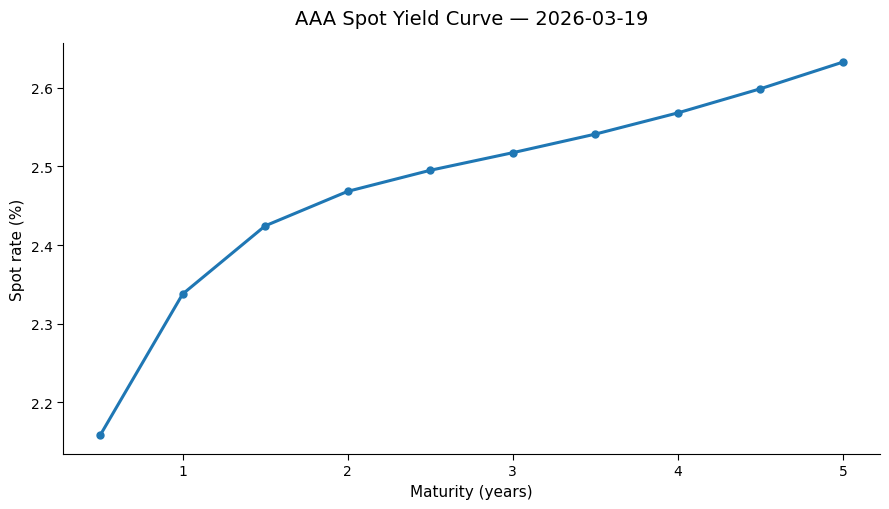

In [4]:
import matplotlib.pyplot as plt


# Convert to percentage only for display
x = df_curve["maturity_years"]
y = df_curve["spot_rate"] * 100

plt.figure(figsize=(9, 5.2))
plt.plot(
    x, y,
    linewidth=2.2,
    marker="o",
    markersize=5
)

plt.title(f"AAA Spot Yield Curve — {selected_date.date()}", fontsize=14, pad=14)
plt.xlabel("Maturity (years)", fontsize=11)
plt.ylabel("Spot rate (%)", fontsize=11)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)
ax.grid(False)

plt.tight_layout()
plt.show()

Question4

In [ ]:
# Function to get spot rate by maturity
def get_rate(df, maturity):
    return df.loc[df["maturity_years"] == maturity, "spot_rate"].values[0]

# Define maturities
x1 = 1.0
xi = 1.5
x2 = 2.0

# Extract rates directly from df_curve 
y1 = get_rate(df_curve, x1)
y2 = get_rate(df_curve, x2)
y_obs = get_rate(df_curve, xi)

# Linear interpolation
y_interp = y1 + (y2 - y1) * ((xi - x1) / (x2 - x1))

# Errors
error = y_obs - y_interp
error_bps = error * 10000  # decimal to bps

print(f"Interpolated rate: {y_interp:.6f}")
print(f"Observed rate:     {y_obs:.6f}")
print(f"Difference:        {error:.6f}")
print(f"Difference (bps):  {error_bps:.2f}")

Interpolated rate: 0.024030
Observed rate:     0.024244
Difference:        0.000214
Difference (bps):  2.14


Question 5

In [8]:
# Question 5: Calculating price of STRIPS

PAR_VALUE = 100
m = 2  # semi-annual compounding

df_strips = df_curve.copy()

df_strips["strip_price"] = PAR_VALUE / ((1 + df_strips["spot_rate"] / m) ** (m * df_strips["maturity_years"]))

# optional display columns
df_strips["spot_rate_pct"] = df_strips["spot_rate"] * 100

df_strips = df_strips[["date", "maturity_label", "maturity_years", "spot_rate_pct", "strip_price"]]

print(df_strips.to_string(index=False))

      date maturity_label  maturity_years  spot_rate_pct  strip_price
2026-03-19           0.5Y             0.5       2.158183    98.932429
2026-03-19           1.0Y             1.0       2.337735    97.702623
2026-03-19           1.5Y             1.5       2.424372    96.449856
2026-03-19           2.0Y             2.0       2.468185    95.212249
2026-03-19           2.5Y             2.5       2.494950    93.989425
2026-03-19           3.0Y             3.0       2.517302    92.769919
2026-03-19           3.5Y             3.5       2.540909    91.542061
2026-03-19           4.0Y             4.0       2.567863    90.297472
2026-03-19           4.5Y             4.5       2.598506    89.031525
2026-03-19           5.0Y             5.0       2.632398    87.742725


# STRIPS pricing from spot rates

To compute the price of each STRIP, we reverse the standard formula. A STRIP is a zero-coupon bond, so its price is given by discounting its face value using the corresponding spot rate:

$$P = \frac{FV}{(1 + y)^T}$$

Where:

| Symbol | Definition |
|--------|------------|
| $P$ | Price of the STRIP |
| $FV$ | Face value |
| $y$ | Spot rate |
| $T$ | Maturity in years |


## Interpretation

All computed STRIP prices are below par (100). This is expected because all spot rates are positive. Since future cash flows are discounted at positive interest rates, their present value must be lower than the face value.

Additionally, as maturity increases, STRIP prices decrease further. This reflects the time value of money: the longer the time to maturity, the greater the discounting effect.

Question 6

Forward Rate and Forward Yield Curve

A forward rate represents the interest rate of a future period.

**The main characteristics of a forward rate are:**

- the forward rate discounts cash flows by one period;
- assuming one period is 6 months, the forward rate discounts cash flows from one future date back to the previous date;
- investors are indifferent between an investment with a spot rate or with a forward rate, as the return is the same;
- the forward yield curve is the graph that shows the relationship between forward rates and maturity.

## Deriving forward rates from spot rates

Forward rates are derived from spot rates. To deduce a forward rate $f(t)$, the following equation is applied:

$$\left(1+\frac{s_t}{m}\right)^l = \left(1+\frac{s_{t-1}}{m}\right)^{l-1} \cdot \left(1+\frac{f(t)}{m}\right)$$

**Where:**

| Symbol | Definition |
|--------|------------|
| $s_t$ | Spot rate at time $t$ |
| $s_{t-1}$ | Spot rate at time $t-1$ |
| $l$ | Number of periods |
| $m$ | Number of periods per year |
| $f(t)$ | Forward rate corresponding to the spot rate $s_t$ |


## Application: semi-annual periods

In our case, we use semi-annual periods, so:

- One period = 6 months
- $m = 2$

Therefore, for each maturity, the forward rate is derived from two consecutive spot rates.

In [9]:
m = 2  # number of periods per year

df_forward = df_curve.copy().sort_values("maturity_years").reset_index(drop=True)

forward_rates = []

for i in range(len(df_forward)):
    t = df_forward.loc[i, "maturity_years"]
    s_t = df_forward.loc[i, "spot_rate"]
    l = int(t * m)  # number of periods

    if i == 0:
        f_t = s_t
    else:
        s_t_minus_1 = df_forward.loc[i - 1, "spot_rate"]

        f_t = m * (
            ((1 + s_t / m) ** l) /
            ((1 + s_t_minus_1 / m) ** (l - 1))
            - 1
        )

    forward_rates.append(f_t)

df_forward["forward_rate"] = forward_rates
df_forward["spot_rate_pct"] = df_forward["spot_rate"] * 100
df_forward["forward_rate_pct"] = df_forward["forward_rate"] * 100

print(
    df_forward[
        ["maturity_label", "maturity_years", "spot_rate_pct", "forward_rate_pct"]
    ].round(4).to_string(index=False)
)

maturity_label  maturity_years  spot_rate_pct  forward_rate_pct
          0.5Y             0.5         2.1582            2.1582
          1.0Y             1.0         2.3377            2.5174
          1.5Y             1.5         2.4244            2.5978
          2.0Y             2.0         2.4682            2.5997
          2.5Y             2.5         2.4949            2.6020
          3.0Y             3.0         2.5173            2.6291
          3.5Y             3.5         2.5409            2.6826
          4.0Y             4.0         2.5679            2.7566
          4.5Y             4.5         2.5985            2.8438
          5.0Y             5.0         2.6324            2.9377


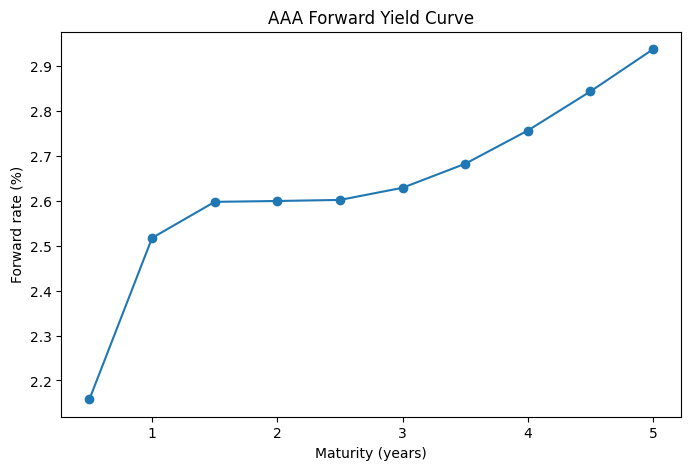

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_forward["maturity_years"], df_forward["forward_rate_pct"], marker="o")

plt.title("AAA Forward Yield Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Forward rate (%)")

plt.show()

Question 7

In [ ]:
# Variables

FV = 1000
r = 0.02
freq = 2 # paid semi-annually
coupon = FV * r / freq

n_periods = 3 * freq

times = []
for i in range(1, n_periods + 1):
    times.append(i / freq)

cash_flows = []
for i in range(1, n_periods + 1):
    if i < n_periods:
        cash_flows.append(coupon)
    else:
        cash_flows.append(coupon + FV)

print(times)
print(cash_flows)

# Spot rates for 02/01/2025, at semi-annual maturities from 6 months to 3 years

spot_rates = [
    0.02425927,
    0.02191738,
    0.02066626,
    0.02007620,
    0.01988808,
    0.01994412
]

# Calcualte price using spot rates

price_spot = 0

for cf, t, s in zip(cash_flows, times, spot_rates):
    pv = cf / (1 + s / freq) ** (t * freq)
    price_spot += pv

print("Bond price using spot rates:", price_spot)

# Derive forward rates from spot rates

forward_rates = []

for i in range(len(spot_rates)):
    t = times[i]
    s_t = spot_rates[i]
    l = int(t * freq)   # number of semi-annual periods

    if i == 0:
        f_t = s_t
    else:
        s_prev = spot_rates[i - 1]

        f_t = freq * (
            ((1 + s_t / freq) ** l) /
            ((1 + s_prev / freq) ** (l - 1))
            - 1
        )

    forward_rates.append(f_t)

print("Forward rates:", forward_rates)

price_forward = 0

for i in range(len(cash_flows)):
    discount_factor = 1

    for j in range(i + 1):
        discount_factor *= (1 + forward_rates[j] / freq)

    pv = cash_flows[i] / discount_factor
    price_forward += pv

print("Bond price using forward rates:", price_forward)

[0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
[10.0, 10.0, 10.0, 10.0, 10.0, 1010.0]
Bond price using spot rates: 1000.1101122901654
Forward rates: [0.02425927, 0.019578199360828386, 0.01816634202128231, 0.018307053628467962, 0.019135775170811442, 0.02022434332256262]
Bond price using forward rates: 1000.1101122901654


## Observation

The price of a bond using spot rates and forward rates are the same. This is because forward rates are implied by the spot-rate curve, so both approaches use the same information from the term structure of interest rates. The spot-rate method discounts each cash flow directly to today, while the forward-rate method discounts the cash flows period by period. 

Question 8

Question 9

Question 10

Question 11